# Musterlösung – Aufgabenblatt 6

## Eindimensionale Analysis – Unbestimmte Integrale

In [169]:
# ── Imports & Setup ────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sympy import *

x, t, u = symbols('x t u', real=True)

init_printing(use_latex='mathjax')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#ccc',
    'xtick.color':      '#888',
    'ytick.color':      '#888',
    'grid.color':       '#222',
    'grid.linewidth':   0.6,
    'text.color':       '#eee',
    'font.family':      'monospace',
    'figure.dpi':       120,
})

CYAN   = '#00e5ff'
ORANGE = '#ff6e3a'
GREEN  = '#39ff14'
PINK   = '#ff4fcf'

print('Setup fertig ✓')

Setup fertig ✓


---
## Aufgabe 1

$$\int \frac{dx}{x\log x}$$

### Analytische Lösung – Substitution

*(Hier bezeichnet $\log$ den natürlichen Logarithmus $\ln$.)*

**Beobachtung:** Der Integrand enthält $\log x$ und dessen Ableitung $\frac{1}{x}$. Das deutet auf die Substitution $u = \log x$ hin.

**Schritt 1 – Substitution wählen:**
$$u = \log x \implies \frac{du}{dx} = \frac{1}{x} \implies du = \frac{dx}{x}$$

**Schritt 2 – Integral umschreiben:**
$$\int \frac{dx}{x \log x} = \int \frac{1}{\log x} \cdot \frac{dx}{x} = \int \frac{du}{u}$$

**Schritt 3 – Standardintegral auswerten:**
$$\int \frac{du}{u} = \log|u| + C$$

**Schritt 4 – Rücksubstitution $u = \log x$:**
$$= \log|\log x| + C$$

$$\boxed{\int \frac{dx}{x\log x} = \log|\log x| + C}$$

SymPy-Stammfunktion: log(log(x))
Ableitung (Probe):   0


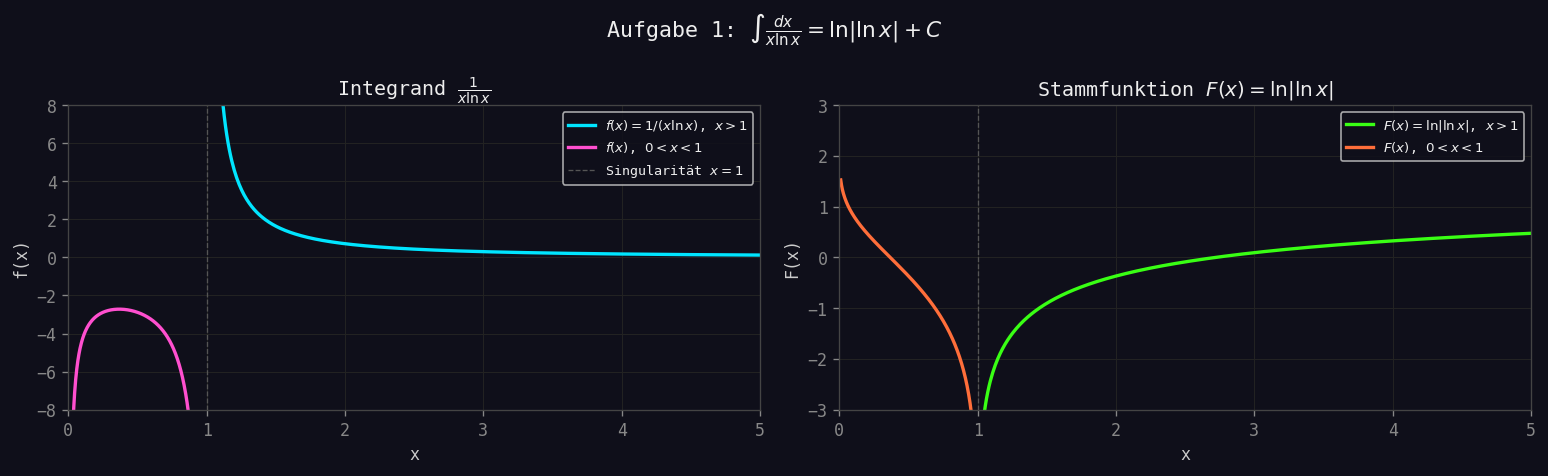

In [170]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f1 = 1 / (x * log(x))
F1 = integrate(f1, x)
print('SymPy-Stammfunktion:', F1)
print('Ableitung (Probe):  ', simplify(diff(F1, x) - f1))  # soll 0 sein

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Links: Integrand 1/(x ln x)
ax = axes[0]
x_pos = np.linspace(1.01, 10, 1000)          # x > 1  →  ln x > 0
x_neg = np.linspace(0.01, 0.99, 500)         # 0 < x < 1  →  ln x < 0
ax.plot(x_pos, 1/(x_pos*np.log(x_pos)), color=CYAN,  lw=2, label=r'$f(x) = 1/(x\ln x)$, $x>1$')
ax.plot(x_neg, 1/(x_neg*np.log(x_neg)), color=PINK,  lw=2, label=r'$f(x)$, $0<x<1$')
ax.axvline(1, color='#555', lw=0.8, ls='--', label='Singularität $x=1$')
ax.set(xlim=(0, 5), ylim=(-8, 8), xlabel='x', ylabel='f(x)',
       title=r'Integrand $\frac{1}{x\ln x}$')
ax.grid(True); ax.legend(fontsize=8)

# Rechts: Stammfunktion ln|ln x|
ax = axes[1]
ax.plot(x_pos, np.log(np.abs(np.log(x_pos))), color=GREEN, lw=2, label=r'$F(x) = \ln|\ln x|$, $x>1$')
ax.plot(x_neg, np.log(np.abs(np.log(x_neg))), color=ORANGE, lw=2, label=r'$F(x)$, $0<x<1$')
ax.axvline(1, color='#555', lw=0.8, ls='--')
ax.set(xlim=(0, 5), ylim=(-3, 3), xlabel='x', ylabel='F(x)',
       title=r'Stammfunktion $F(x) = \ln|\ln x|$')
ax.grid(True); ax.legend(fontsize=8)

fig.suptitle(r'Aufgabe 1: $\int \frac{dx}{x\ln x} = \ln|\ln x| + C$', fontsize=13)
plt.tight_layout()
plt.show()

---
## Aufgabe 2

$$\int \sin x\cos x\,dx$$

### Analytische Lösung – Partielle Integration

Die Formel der partiellen Integration lautet: $\displaystyle\int u\,dv = uv - \int v\,du$.

**Wahl:**
$$u = \sin x \implies du = \cos x\,dx$$
$$dv = \cos x\,dx \implies v = \sin x$$

**Schritt 1 – Formel anwenden:**
$$\int \sin x\cos x\,dx = \sin x \cdot \sin x - \int \sin x \cdot \cos x\,dx$$
$$= \sin^2 x - \int \sin x\cos x\,dx$$

**Schritt 2 – Das Integral erscheint auf der rechten Seite erneut. Umstellen:**
$$2\int \sin x\cos x\,dx = \sin^2 x$$
$$\int \sin x\cos x\,dx = \frac{\sin^2 x}{2} + C$$

**Das Ergebnis kann äquivalent durch Substitution erhalten werden:**
$u = \sin x$: $du = \cos x\,dx \implies \int u\,du = \frac{u^2}{2} = \frac{\sin^2 x}{2}$. ✓

$$\boxed{\int \sin x\cos x\,dx = \frac{\sin^2 x}{2} + C}$$

SymPy-Stammfunktion: sin(x)**2/2
Vereinfacht:         sin(x)**2/2
Probe (soll 0):      0


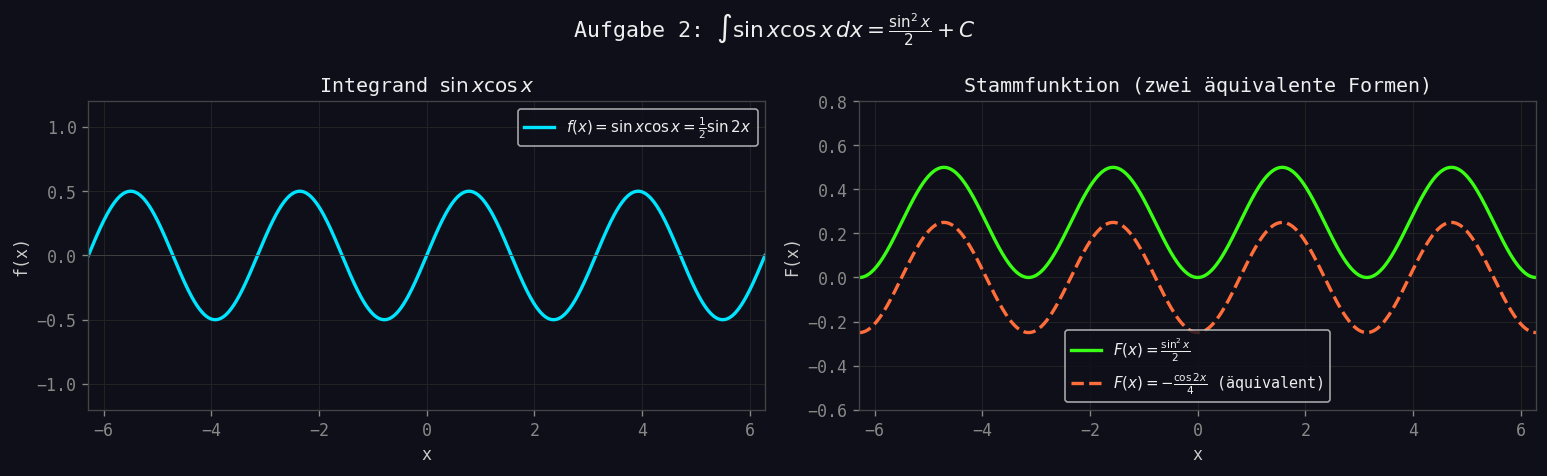

In [171]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f2 = sin(x) * cos(x)
F2 = integrate(f2, x)
print('SymPy-Stammfunktion:', F2)
print('Vereinfacht:        ', trigsimp(F2))
print('Probe (soll 0):     ', simplify(diff(F2, x) - f2))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.linspace(-2*np.pi, 2*np.pi, 800)

ax = axes[0]
ax.plot(x_vals, np.sin(x_vals)*np.cos(x_vals), color=CYAN, lw=2,
        label=r'$f(x) = \sin x \cos x = \frac{1}{2}\sin 2x$')
ax.axhline(0, color='#444', lw=0.5)
ax.set(xlim=(-2*np.pi, 2*np.pi), ylim=(-1.2, 1.2),
       xlabel='x', ylabel='f(x)', title=r'Integrand $\sin x\cos x$')
ax.grid(True); ax.legend(fontsize=9)

ax = axes[1]
ax.plot(x_vals, np.sin(x_vals)**2 / 2, color=GREEN, lw=2,
        label=r'$F(x) = \frac{\sin^2 x}{2}$')
ax.plot(x_vals, -np.cos(2*x_vals)/4, color=ORANGE, lw=2, ls='--',
        label=r'$F(x) = -\frac{\cos 2x}{4}$ (äquivalent)')
ax.set(xlim=(-2*np.pi, 2*np.pi), ylim=(-0.6, 0.8),
       xlabel='x', ylabel='F(x)', title=r'Stammfunktion (zwei äquivalente Formen)')
ax.grid(True); ax.legend(fontsize=9)

fig.suptitle(r'Aufgabe 2: $\int \sin x\cos x\,dx = \frac{\sin^2 x}{2} + C$', fontsize=13)
plt.tight_layout()
plt.show()

---
## Aufgabe 3

$$\int x\arctan x\,dx$$

### Analytische Lösung – Partielle Integration

**Wahl** (Faustregel: ILATE – inverse trigonometrische Funktionen zuerst als $u$):
$$u = \arctan x \implies du = \frac{dx}{1+x^2}$$
$$dv = x\,dx \implies v = \frac{x^2}{2}$$

**Schritt 1 – Partielle Integration anwenden:**
$$\int x\arctan x\,dx = \frac{x^2}{2}\arctan x - \int \frac{x^2}{2} \cdot \frac{1}{1+x^2}\,dx$$
$$= \frac{x^2}{2}\arctan x - \frac{1}{2}\int \frac{x^2}{1+x^2}\,dx$$

**Schritt 2 – Restintegral vereinfachen:**  
Algebraische Umformung des Bruchs:
$$\frac{x^2}{1+x^2} = 1 - \frac{1}{1+x^2}$$

Daher:
$$\frac{1}{2}\int \frac{x^2}{1+x^2}\,dx = \frac{1}{2}\int \left(1 - \frac{1}{1+x^2}\right)dx = \frac{1}{2}\left(x - \arctan x\right) + C$$

**Schritt 3 – Zusammensetzen:**
$$\int x\arctan x\,dx = \frac{x^2}{2}\arctan x - \frac{1}{2}x + \frac{1}{2}\arctan x + C$$
$$= \frac{x^2+1}{2}\arctan x - \frac{x}{2} + C$$

$$\boxed{\int x\arctan x\,dx = \frac{x^2+1}{2}\arctan x - \frac{x}{2} + C}$$

SymPy-Stammfunktion: x**2*atan(x)/2 - x/2 + atan(x)/2
Vereinfacht:         x**2*atan(x)/2 - x/2 + atan(x)/2
Probe (soll 0):      0
Differenz Hand/SymPy: 0


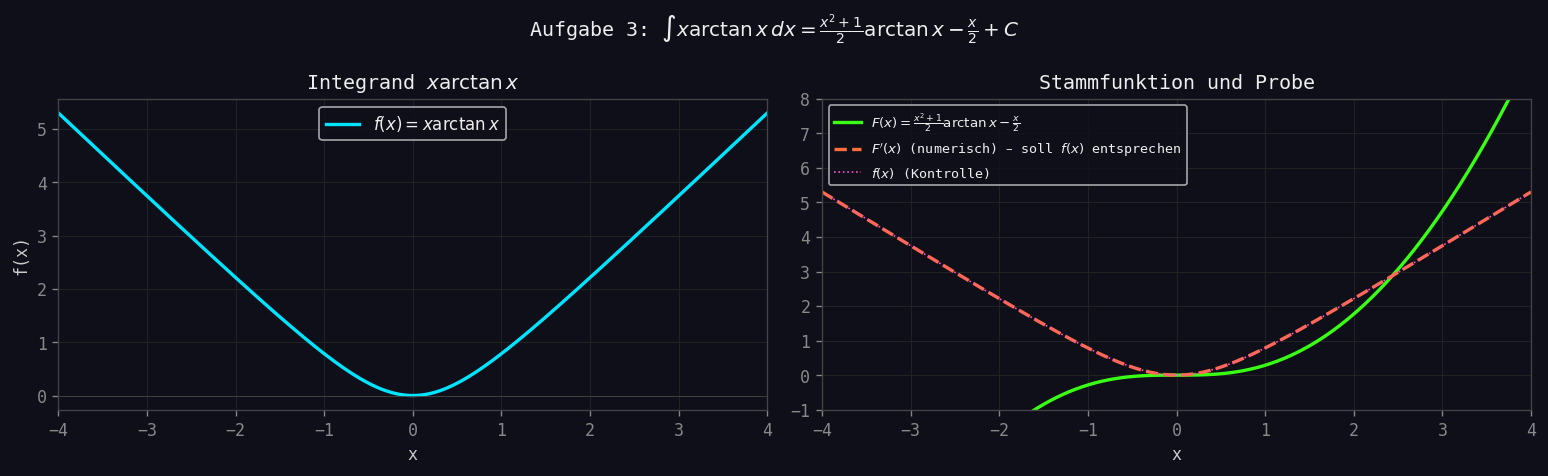

In [172]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f3 = x * atan(x)
F3 = integrate(f3, x)
print('SymPy-Stammfunktion:', F3)
print('Vereinfacht:        ', simplify(F3))
print('Probe (soll 0):     ', simplify(diff(F3, x) - f3))

# Handrechnung nachvollziehen
F3_hand = (x**2 + 1)/2 * atan(x) - x/2
print('Differenz Hand/SymPy:', simplify(F3 - F3_hand))  # Konstante

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.linspace(-4, 4, 800)

ax = axes[0]
ax.plot(x_vals, x_vals * np.arctan(x_vals), color=CYAN, lw=2,
        label=r'$f(x) = x\arctan x$')
ax.axhline(0, color='#444', lw=0.5)
ax.set(xlim=(-4, 4), xlabel='x', ylabel='f(x)', title=r'Integrand $x\arctan x$')
ax.grid(True); ax.legend()

ax = axes[1]
F3_num = (x_vals**2 + 1)/2 * np.arctan(x_vals) - x_vals/2
ax.plot(x_vals, F3_num, color=GREEN, lw=2,
        label=r'$F(x) = \frac{x^2+1}{2}\arctan x - \frac{x}{2}$')
# Probe: Ableitung
dx = x_vals[1] - x_vals[0]
F3_deriv = np.gradient(F3_num, dx)
ax.plot(x_vals, F3_deriv, color=ORANGE, lw=2, ls='--',
        label=r"$F'(x)$ (numerisch) – soll $f(x)$ entsprechen")
ax.plot(x_vals, x_vals*np.arctan(x_vals), color=PINK, lw=1, ls=':',
        label=r'$f(x)$ (Kontrolle)')
ax.set(xlim=(-4, 4), ylim=(-1, 8), xlabel='x', ylabel='',
       title=r'Stammfunktion und Probe')
ax.grid(True); ax.legend(fontsize=8)

fig.suptitle(r'Aufgabe 3: $\int x\arctan x\,dx = \frac{x^2+1}{2}\arctan x - \frac{x}{2} + C$', fontsize=12)
plt.tight_layout()
plt.show()

---
## Aufgabe 4

$$\int x^2\sin x\,dx$$

### Analytische Lösung – Partielle Integration (zweifach)

Bei Produkten $x^n \cdot \text{(trig)}$ muss die partielle Integration so oft wiederholt werden, bis der Polynomfaktor wegfällt ($n = 2$ erfordert also zwei Schritte).

**1. Partielle Integration:**
$$u_1 = x^2 \implies du_1 = 2x\,dx \qquad dv_1 = \sin x\,dx \implies v_1 = -\cos x$$
$$\int x^2\sin x\,dx = -x^2\cos x + 2\int x\cos x\,dx$$

**2. Partielle Integration** für das Restintegral $\int x\cos x\,dx$:
$$u_2 = x \implies du_2 = dx \qquad dv_2 = \cos x\,dx \implies v_2 = \sin x$$
$$\int x\cos x\,dx = x\sin x - \int \sin x\,dx = x\sin x + \cos x$$

**Schritt 3 – Zusammensetzen:**
$$\int x^2\sin x\,dx = -x^2\cos x + 2\left(x\sin x + \cos x\right) + C$$
$$= -x^2\cos x + 2x\sin x + 2\cos x + C$$

**Schritt 4 – Vereinfachen:**
$$= (2-x^2)\cos x + 2x\sin x + C$$

$$\boxed{\int x^2\sin x\,dx = (2-x^2)\cos x + 2x\sin x + C}$$

SymPy-Stammfunktion: -x**2*cos(x) + 2*x*sin(x) + 2*cos(x)
Vereinfacht:         -x**2*cos(x) + 2*x*sin(x) + 2*cos(x)
Probe (soll 0):      0
Differenz Hand/SymPy: 0


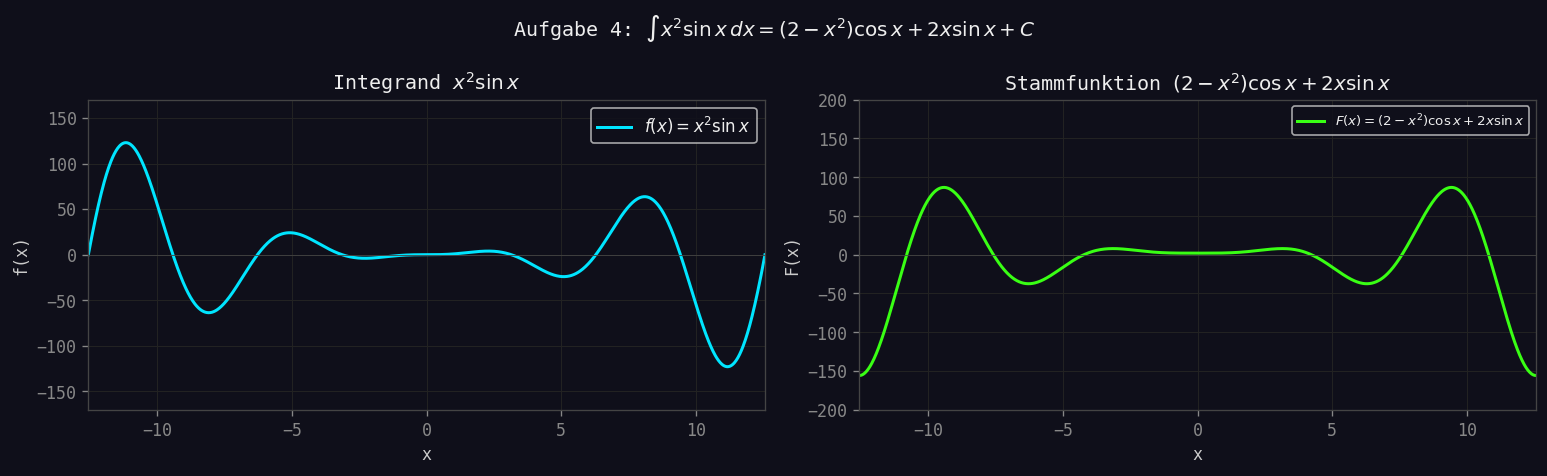

In [173]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f4 = x**2 * sin(x)
F4 = integrate(f4, x)
print('SymPy-Stammfunktion:', F4)
print('Vereinfacht:        ', expand(F4))
print('Probe (soll 0):     ', simplify(diff(F4, x) - f4))

F4_hand = (2 - x**2)*cos(x) + 2*x*sin(x)
print('Differenz Hand/SymPy:', simplify(F4 - F4_hand))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.linspace(-4*np.pi, 4*np.pi, 1200)

ax = axes[0]
ax.plot(x_vals, x_vals**2 * np.sin(x_vals), color=CYAN, lw=1.8,
        label=r'$f(x) = x^2\sin x$')
ax.axhline(0, color='#444', lw=0.5)
ax.set(xlim=(-4*np.pi, 4*np.pi), ylim=(-170, 170),
       xlabel='x', ylabel='f(x)', title=r'Integrand $x^2\sin x$')
ax.grid(True); ax.legend()

ax = axes[1]
F4_num = (2 - x_vals**2)*np.cos(x_vals) + 2*x_vals*np.sin(x_vals)
ax.plot(x_vals, F4_num, color=GREEN, lw=1.8,
        label=r'$F(x) = (2-x^2)\cos x + 2x\sin x$')
ax.axhline(0, color='#444', lw=0.5)
ax.set(xlim=(-4*np.pi, 4*np.pi), ylim=(-200, 200),
       xlabel='x', ylabel='F(x)', title=r'Stammfunktion $(2-x^2)\cos x + 2x\sin x$')
ax.grid(True); ax.legend(fontsize=8)

fig.suptitle(r'Aufgabe 4: $\int x^2\sin x\,dx = (2-x^2)\cos x + 2x\sin x + C$', fontsize=12)
plt.tight_layout()
plt.show()

---
## Aufgabe 5

$$\int \log x\,dx$$

### Analytische Lösung – Partielle Integration

*(Hier: $\log = \ln$, natürlicher Logarithmus.)*

**Trick:** Man schreibt $\log x = \log x \cdot 1$ und integriert den konstanten Faktor $1$.

**Wahl:**
$$u = \log x \implies du = \frac{1}{x}\,dx$$
$$dv = 1\,dx \implies v = x$$

**Schritt 1 – Partielle Integration:**
$$\int \log x\,dx = x\log x - \int x \cdot \frac{1}{x}\,dx = x\log x - \int 1\,dx$$

**Schritt 2 – Restintegral:**
$$\int 1\,dx = x$$

**Schritt 3 – Ergebnis:**
$$\int \log x\,dx = x\log x - x + C = x(\log x - 1) + C$$

$$\boxed{\int \log x\,dx = x\log x - x + C}$$

SymPy-Stammfunktion: x*log(x) - x
Probe (soll 0):      0
Differenz Hand/SymPy: 0
Nullstelle F(x) = 0: [E] → F(e) = 0


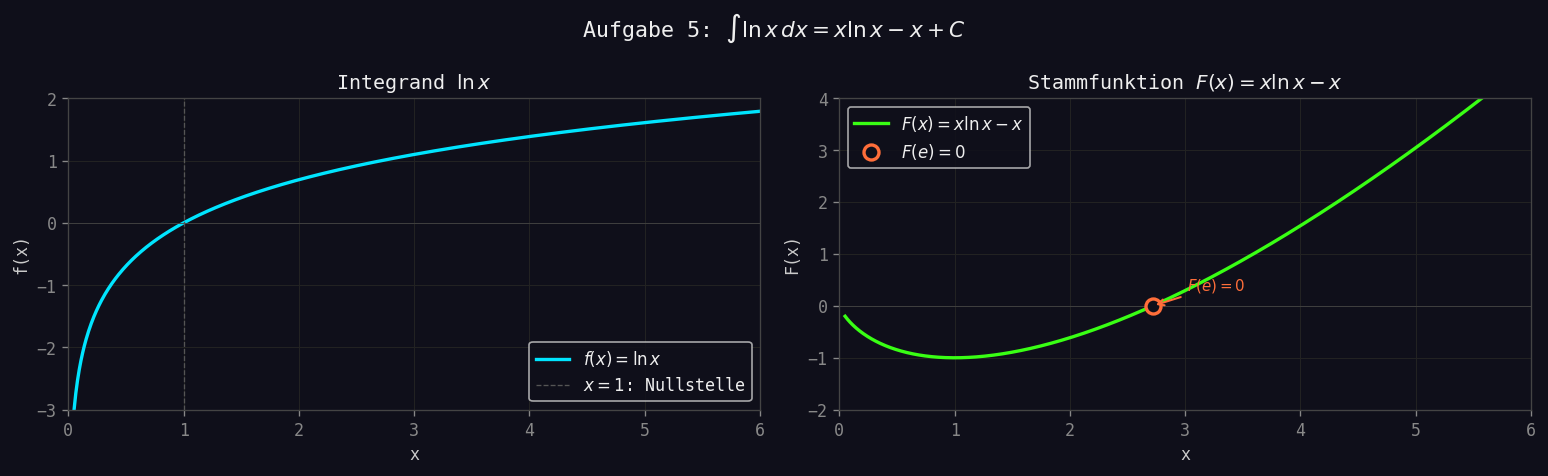

In [174]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f5 = log(x)
F5 = integrate(f5, x)
print('SymPy-Stammfunktion:', F5)
print('Probe (soll 0):     ', simplify(diff(F5, x) - f5))

F5_hand = x*log(x) - x
print('Differenz Hand/SymPy:', simplify(F5 - F5_hand))

# Nullstelle der Stammfunktion bestimmen
zero = solve(F5_hand, x)
print('Nullstelle F(x) = 0:', zero, '→ F(e) =', F5_hand.subs(x, E))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x_vals = np.linspace(0.05, 6, 800)

ax = axes[0]
ax.plot(x_vals, np.log(x_vals), color=CYAN, lw=2, label=r'$f(x) = \ln x$')
ax.axhline(0, color='#444', lw=0.5)
ax.axvline(1, color='#555', lw=0.8, ls='--', label='$x=1$: Nullstelle')
ax.set(xlim=(0, 6), ylim=(-3, 2), xlabel='x', ylabel='f(x)',
       title=r'Integrand $\ln x$')
ax.grid(True); ax.legend()

ax = axes[1]
F5_num = x_vals * np.log(x_vals) - x_vals
ax.plot(x_vals, F5_num, color=GREEN, lw=2, label=r'$F(x) = x\ln x - x$')
ax.axhline(0, color='#444', lw=0.5)
ax.plot(np.e, 0, 'o', color=ORANGE, markersize=9,
        markerfacecolor='#0f0f1a', markeredgewidth=2, label=r'$F(e) = 0$')
ax.annotate(r'$F(e)=0$', xy=(np.e, 0), xytext=(np.e+0.3, 0.3),
            color=ORANGE, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2))
ax.set(xlim=(0, 6), ylim=(-2, 4), xlabel='x', ylabel='F(x)',
       title=r'Stammfunktion $F(x) = x\ln x - x$')
ax.grid(True); ax.legend()

fig.suptitle(r'Aufgabe 5: $\int \ln x\,dx = x\ln x - x + C$', fontsize=13)
plt.tight_layout()
plt.show()

---
## Aufgabe 6

Berechnen Sie $\displaystyle\int \frac{dx}{\sin x}$.  
**Hinweis:** Verwenden Sie die Substitution $u = \tan\dfrac{x}{2}$.

### Analytische Lösung – Weierstraß-Substitution

**Schritt 1 – Vorbereitende Formeln herleiten:**

Sei $u = \tan\dfrac{x}{2}$. Mit den Halbwinkelformeln gilt:

$$\sin x = \frac{2\tan\frac{x}{2}}{1 + \tan^2\frac{x}{2}} = \frac{2u}{1+u^2}$$

$$\cos x = \frac{1-\tan^2\frac{x}{2}}{1+\tan^2\frac{x}{2}} = \frac{1-u^2}{1+u^2}$$

**Differenzial:** Aus $u = \tan\dfrac{x}{2}$ folgt
$$\frac{du}{dx} = \frac{1}{2}\sec^2\!\frac{x}{2} = \frac{1}{2}\left(1 + \tan^2\frac{x}{2}\right) = \frac{1+u^2}{2}$$

$$\implies dx = \frac{2\,du}{1+u^2}$$

**Schritt 2 – Integral umschreiben:**
$$\int \frac{dx}{\sin x} = \int \frac{1}{\dfrac{2u}{1+u^2}} \cdot \frac{2\,du}{1+u^2}$$

$$= \int \frac{1+u^2}{2u} \cdot \frac{2}{1+u^2}\,du = \int \frac{du}{u}$$

**Schritt 3 – Auswerten:**
$$\int \frac{du}{u} = \log|u| + C$$

**Schritt 4 – Rücksubstitution** $u = \tan\dfrac{x}{2}$:
$$= \log\!\left|\tan\frac{x}{2}\right| + C$$

$$\boxed{\int \frac{dx}{\sin x} = \log\!\left|\tan\frac{x}{2}\right| + C}$$

**Probe:** Die Ableitung von $\log\!\left|\tan\dfrac{x}{2}\right|$ ist:
$$\frac{d}{dx}\log\!\left|\tan\frac{x}{2}\right| = \frac{1}{\tan\frac{x}{2}} \cdot \frac{1}{\cos^2\frac{x}{2}} \cdot \frac{1}{2} = \frac{\cos\frac{x}{2}}{\sin\frac{x}{2}} \cdot \frac{1}{2\cos^2\frac{x}{2}} = \frac{1}{2\sin\frac{x}{2}\cos\frac{x}{2}} = \frac{1}{\sin x} \checkmark$$

(Dabei wurde $\sin x = 2\sin\dfrac{x}{2}\cos\dfrac{x}{2}$ verwendet.)

**Alternativer Ausdruck:** Mit $\log|\tan\frac{x}{2}| = \log\left|\frac{\sin\frac{x}{2}}{\cos\frac{x}{2}}\right|$ und trigonometrischen Identitäten lässt sich zeigen:
$$\log\!\left|\tan\frac{x}{2}\right| = \log\!\left|\frac{1-\cos x}{\sin x}\right| = \log|\csc x - \cot x|$$

Alle drei Formen sind äquivalent (unterscheiden sich nur um eine Konstante).

In [175]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f6 = 1 / sin(x)
F6 = integrate(f6, x)
print('SymPy-Stammfunktion:         ', F6)
print('Probe – Ableitung (soll 0):  ', simplify(diff(F6, x) - f6))

# Handrechnung: log|tan(x/2)|
F6_hand = log(Abs(tan(x/2)))
print('\nHandrechnung F(x) = log|tan(x/2)|')
print('Ableitung (soll 1/sin x):    ', simplify(diff(F6_hand, x)))
print('Vereinfacht:                 ', trigsimp(diff(F6_hand, x)))

# Äquivalente Formen zeigen
F6_alt1 = log(Abs(1/sin(x) - cos(x)/sin(x)))
print('\nÄquivalenz log|csc x - cot x|:')
print('Ableitung:', simplify(diff(F6_alt1, x)))

# Weierstraß-Substitution Schritt für Schritt in SymPy
print('\n── Weierstraß-Substitution manuell ─────────────────────')
u_sym = symbols('u', positive=True)
sin_sub  = 2*u_sym / (1 + u_sym**2)
dx_sub   = 2 / (1 + u_sym**2)
integrand_u = (1/sin_sub) * dx_sub
print('Integrand nach Substitution: ', simplify(integrand_u), '  → ∫ du/u')
print('Integral in u:               log(u) + C')
print('Rücksubstitution:            log|tan(x/2)| + C')

SymPy-Stammfunktion:          log(cos(x) - 1)/2 - log(cos(x) + 1)/2
Probe – Ableitung (soll 0):   0

Handrechnung F(x) = log|tan(x/2)|
Ableitung (soll 1/sin x):     Piecewise((0, Eq(tan(x/2), 0)), (1/sin(x), True))
Vereinfacht:                  sign(tan(x/2))/(2*cos(x/2)**2*Abs(tan(x/2)))

Äquivalenz log|csc x - cot x|:
Ableitung: Piecewise((0, Eq((cos(x) - 1)/sin(x), 0)), (1/sin(x), True))

── Weierstraß-Substitution manuell ─────────────────────
Integrand nach Substitution:  1/u   → ∫ du/u
Integral in u:               log(u) + C
Rücksubstitution:            log|tan(x/2)| + C


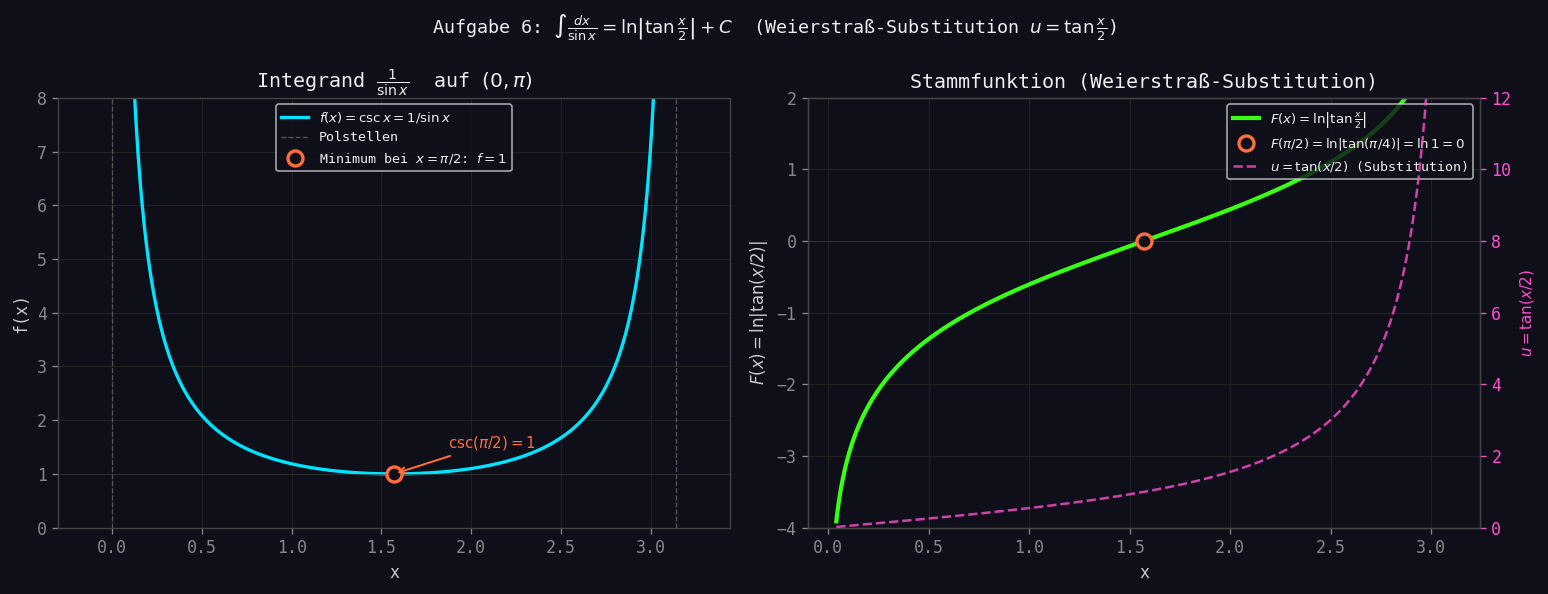

In [176]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Wir plotten auf (0, π) – erstes Intervall, auf dem sin x > 0
eps = 0.04
x_seg = np.linspace(eps, np.pi - eps, 800)

# Links: Integrand 1/sin(x) = csc(x)
ax = axes[0]
ax.plot(x_seg, 1/np.sin(x_seg), color=CYAN, lw=2, label=r'$f(x) = \csc x = 1/\sin x$')
ax.axvline(0,      color='#555', lw=0.8, ls='--', label='Polstellen')
ax.axvline(np.pi,  color='#555', lw=0.8, ls='--')
ax.axhline(1,      color='#333', lw=0.4)
# Minimum bei x=π/2
ax.plot(np.pi/2, 1, 'o', color=ORANGE, markersize=9,
        markerfacecolor='#0f0f1a', markeredgewidth=2, label=r'Minimum bei $x=\pi/2$: $f=1$')
ax.annotate(r'$\csc(\pi/2)=1$', xy=(np.pi/2, 1), xytext=(np.pi/2+0.3, 1.5),
            color=ORANGE, fontsize=9,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.2))
ax.set(xlim=(-0.3, np.pi+0.3), ylim=(0, 8),
       xlabel='x', ylabel='f(x)', title=r'Integrand $\frac{1}{\sin x}$  auf $(0,\pi)$')
ax.grid(True); ax.legend(fontsize=8)

# Rechts: Stammfunktion log|tan(x/2)| mit Weierstraß-Geometrie
ax = axes[1]
F_num = np.log(np.abs(np.tan(x_seg/2)))
ax.plot(x_seg, F_num, color=GREEN, lw=2.5,
        label=r'$F(x) = \ln\!\left|\tan\frac{x}{2}\right|$')
ax.axhline(0, color='#333', lw=0.6)
ax.plot(np.pi/2, 0, 'o', color=ORANGE, markersize=9,
        markerfacecolor='#0f0f1a', markeredgewidth=2,
        label=r'$F(\pi/2)=\ln|\tan(\pi/4)|=\ln 1=0$')
# Zur Visualisierung der Substitution: u = tan(x/2)
u_vals = np.tan(x_seg/2)
ax2 = ax.twinx()
ax2.plot(x_seg, u_vals, color=PINK, lw=1.5, ls='--', alpha=0.8,
         label=r'$u = \tan(x/2)$ (Substitution)')
ax2.set_ylabel(r'$u = \tan(x/2)$', color=PINK, fontsize=9)
ax2.tick_params(axis='y', colors=PINK)
ax2.set_ylim(0, 12)

ax.set(xlim=(-0.1, np.pi+0.1), ylim=(-4, 2),
       xlabel='x', ylabel=r'$F(x) = \ln|\tan(x/2)|$',
       title=r'Stammfunktion (Weierstraß-Substitution)')
ax.grid(True)

# Kombinations-Legende
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

fig.suptitle(r'Aufgabe 6: $\int \frac{dx}{\sin x} = \ln\!\left|\tan\frac{x}{2}\right| + C$  '
             r'(Weierstraß-Substitution $u=\tan\frac{x}{2}$)', fontsize=11)
plt.tight_layout()
plt.show()

---
## Aufgabe 7

Berechnen Sie $\displaystyle\int x^2\sqrt{1-x^2}\,dx$.  
**Hinweis:** Verwenden Sie die Substitution $x = \sin t$.

### Analytische Lösung – Trigonometrische Substitution

**Schritt 1 – Substitution:**
$$x = \sin t \implies dx = \cos t\,dt$$

Für den Wurzelausdruck (mit $t \in [-\frac{\pi}{2}, \frac{\pi}{2}]$, sodass $\cos t \geq 0$):
$$\sqrt{1-x^2} = \sqrt{1-\sin^2 t} = \sqrt{\cos^2 t} = \cos t$$

**Schritt 2 – Integral umschreiben:**
$$\int x^2\sqrt{1-x^2}\,dx = \int \sin^2 t \cdot \cos t \cdot \cos t\,dt = \int \sin^2 t\cos^2 t\,dt$$

**Schritt 3 – Doppelwinkelformel anwenden:**
$$\sin^2 t\cos^2 t = \left(\sin t\cos t\right)^2 = \left(\frac{\sin 2t}{2}\right)^2 = \frac{\sin^2 2t}{4}$$

Weitere Vereinfachung mit $\sin^2 2t = \dfrac{1-\cos 4t}{2}$:
$$\frac{\sin^2 2t}{4} = \frac{1-\cos 4t}{8}$$

**Schritt 4 – Integrieren:**
$$\int \frac{1-\cos 4t}{8}\,dt = \frac{t}{8} - \frac{\sin 4t}{32} + C$$

**Schritt 5 – Rücksubstitution** $t = \arcsin x$:

Für $\sin 4t$ verwenden wir $\sin 4t = 2\sin 2t\cos 2t = 4\sin t\cos t(1-2\sin^2 t)$:
$$\sin 4t = 4x\sqrt{1-x^2}(1-2x^2)$$

Damit:
$$\int x^2\sqrt{1-x^2}\,dx = \frac{\arcsin x}{8} - \frac{x\sqrt{1-x^2}(1-2x^2)}{8} + C$$

**Vereinfachung** durch Ausklammern:
$$= \frac{1}{8}\left[\arcsin x - x\sqrt{1-x^2}(1-2x^2)\right] + C$$

$$\boxed{\int x^2\sqrt{1-x^2}\,dx = \frac{\arcsin x}{8} - \frac{x(1-2x^2)\sqrt{1-x^2}}{8} + C}$$

In [ ]:
# ── SymPy-Verifikation Aufgabe 7 ───────────────────────────────────────────────
f7 = x**2 * sqrt(1 - x**2)

# Wir prüfen sicherheitshalber, ob SymPy ein Piecewise-Objekt zurückgibt.
# Wenn ja, filtern wir es. Wenn nein, nehmen wir direkt das Ergebnis.
F7_raw = integrate(f7, x, manual=True)
F7 = F7_raw.args[0][0] if isinstance(F7_raw, Piecewise) else F7_raw

print('SymPy-Stammfunktion:', F7)
print('Probe (soll 0):     ', simplify(diff(F7, x) - f7))

F7_hand = asin(x)/8 - x*(1 - 2*x**2)*sqrt(1 - x**2)/8
print('\nHandrechnung:')
print('F(x) =', F7_hand)
print('Probe:', simplify(diff(F7_hand, x) - f7))
print('Differenz SymPy/Hand:', simplify(F7 - F7_hand))

# Substitution Schritt für Schritt zeigen
print('\n── Substitution x = sin(t) ────────────────────────────')
t_sym = symbols('t', real=True)
integrand_t = sin(t_sym)**2 * sqrt(1 - sin(t_sym)**2) * cos(t_sym)
integrand_t_simplified = integrand_t.subs(sqrt(1 - sin(t_sym)**2), cos(t_sym))

print('Nach Substitution:             ', integrand_t_simplified)
print('= sin²t·cos²t = sin²(2t)/4 =  ', trigsimp(integrand_t_simplified))

F7_t = integrate(integrand_t_simplified, t_sym)
print('Integral in t:                 ', F7_t)
print('Vereinfacht:                   ', trigsimp(F7_t))

SymPy-Stammfunktion: sqrt(1 - x**2)*(x**3/4 - x/8) + asin(x)/8
Probe (soll 0):      0

Handrechnung:
F(x) = -x*(1 - 2*x**2)*sqrt(1 - x**2)/8 + asin(x)/8
Probe: 0
Differenz SymPy/Hand: 0

── Substitution x = sin(t) ────────────────────────────
Nach Substitution:              sin(t)**2*cos(t)**2
= sin²t·cos²t = sin²(2t)/4 =   1/8 - cos(4*t)/8
Integral in t:                  t/8 - sin(2*t)*cos(2*t)/16
Vereinfacht:                    t/8 - sin(4*t)/32


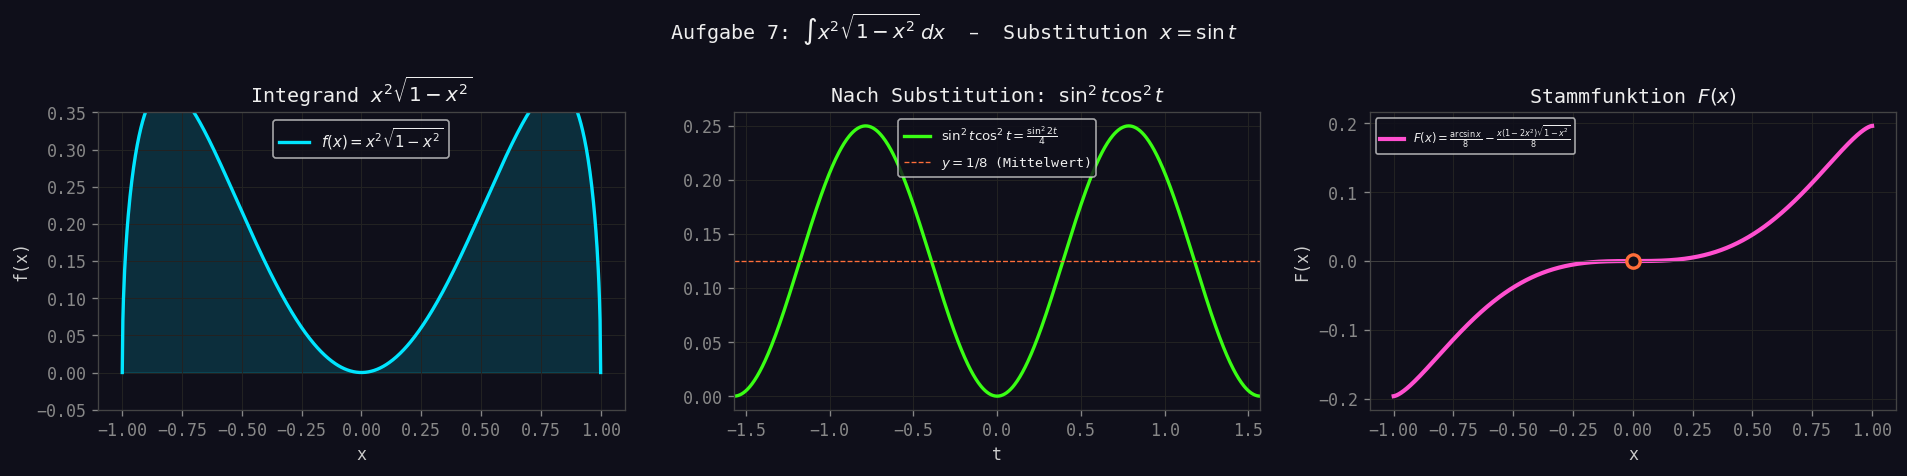

In [178]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x_vals = np.linspace(-1, 1, 800)

# Links: Integrand
ax = axes[0]
ax.plot(x_vals, x_vals**2 * np.sqrt(1 - x_vals**2), color=CYAN, lw=2,
        label=r'$f(x) = x^2\sqrt{1-x^2}$')
ax.fill_between(x_vals, x_vals**2 * np.sqrt(1 - x_vals**2), alpha=0.15, color=CYAN)
ax.set(xlim=(-1.1, 1.1), ylim=(-0.05, 0.35), xlabel='x', ylabel='f(x)',
       title=r'Integrand $x^2\sqrt{1-x^2}$')
ax.grid(True); ax.legend(fontsize=9)

# Mitte: transformierter Integrand in t (nach Substitution)
ax = axes[1]
t_vals = np.linspace(-np.pi/2, np.pi/2, 800)
g_t = np.sin(t_vals)**2 * np.cos(t_vals)**2
ax.plot(t_vals, g_t, color=GREEN, lw=2,
        label=r'$\sin^2 t\cos^2 t = \frac{\sin^2 2t}{4}$')
ax.axhline(1/8, color=ORANGE, lw=0.8, ls='--', label=r'$y = 1/8$ (Mittelwert)')
ax.set(xlim=(-np.pi/2, np.pi/2), xlabel='t', ylabel='',
       title=r'Nach Substitution: $\sin^2 t\cos^2 t$')
ax.grid(True); ax.legend(fontsize=8)

# Rechts: Stammfunktion
ax = axes[2]
F7_num = np.arcsin(x_vals)/8 - x_vals*(1 - 2*x_vals**2)*np.sqrt(1 - x_vals**2)/8
ax.plot(x_vals, F7_num, color=PINK, lw=2.5,
        label=r'$F(x) = \frac{\arcsin x}{8} - \frac{x(1-2x^2)\sqrt{1-x^2}}{8}$')
ax.axhline(0, color='#444', lw=0.5)
ax.plot(0, 0, 'o', color=ORANGE, markersize=8,
        markerfacecolor='#0f0f1a', markeredgewidth=2)
ax.set(xlim=(-1.1, 1.1), xlabel='x', ylabel='F(x)',
       title=r'Stammfunktion $F(x)$')
ax.grid(True); ax.legend(fontsize=7)

fig.suptitle(r'Aufgabe 7: $\int x^2\sqrt{1-x^2}\,dx$  –  Substitution $x=\sin t$', fontsize=12)
plt.tight_layout()
plt.show()

---
## Aufgabe 8

Berechnen Sie $\displaystyle\int x\sqrt{1+x^2}\,dx$.  
**Hinweis:** Verwenden Sie die Substitution $x = \sinh t$.

### Analytische Lösung – Hyperbolische Substitution

**Schritt 1 – Substitution und Schlüsselidentität:**
$$x = \sinh t \implies dx = \cosh t\,dt$$

Für den Wurzelausdruck verwenden wir die **hyperbolische Grundidentität**:
$$\cosh^2 t - \sinh^2 t = 1 \implies 1 + \sinh^2 t = \cosh^2 t$$

Daher (mit $\cosh t > 0$):
$$\sqrt{1+x^2} = \sqrt{1+\sinh^2 t} = \sqrt{\cosh^2 t} = \cosh t$$

**Schritt 2 – Integral umschreiben:**
$$\int x\sqrt{1+x^2}\,dx = \int \sinh t \cdot \cosh t \cdot \cosh t\,dt = \int \sinh t\cosh^2 t\,dt$$

**Schritt 3 – Innere Substitution** $w = \cosh t \implies dw = \sinh t\,dt$:
$$\int \sinh t\cosh^2 t\,dt = \int w^2\,dw = \frac{w^3}{3} + C = \frac{\cosh^3 t}{3} + C$$

**Schritt 4 – Rücksubstitution** $\cosh t = \sqrt{1+\sinh^2 t} = \sqrt{1+x^2}$:
$$= \frac{(\sqrt{1+x^2})^3}{3} + C = \frac{(1+x^2)^{3/2}}{3} + C$$

$$\boxed{\int x\sqrt{1+x^2}\,dx = \frac{(1+x^2)^{3/2}}{3} + C}$$

**Bemerkung:** Dieses Integral kann tatsächlich noch einfacher per direkter Substitution $u = 1+x^2$ gelöst werden:
$$u = 1+x^2 \implies du = 2x\,dx \implies x\,dx = \frac{du}{2}$$
$$\int x\sqrt{1+x^2}\,dx = \int \sqrt{u}\cdot\frac{du}{2} = \frac{1}{2}\cdot\frac{2u^{3/2}}{3} = \frac{u^{3/2}}{3} = \frac{(1+x^2)^{3/2}}{3} + C \checkmark$$

In [179]:
# ── SymPy-Verifikation ─────────────────────────────────────────────────────────
f8 = x * sqrt(1 + x**2)
F8 = integrate(f8, x)
print('SymPy-Stammfunktion:', F8)
print('Vereinfacht:        ', simplify(F8))
print('Probe (soll 0):     ', simplify(diff(F8, x) - f8))

F8_hand = (1 + x**2)**Rational(3,2) / 3
print('\nHandrechnung F(x) = (1+x²)^(3/2) / 3')
print('Probe (soll 0):     ', simplify(diff(F8_hand, x) - f8))
print('Differenz SymPy/Hand:', simplify(F8 - F8_hand))

# Hyperbolische Substitution Schritt für Schritt
print('\n── Hyperbolische Substitution x = sinh(t) ─────────────')
t_sym = symbols('t', real=True)
integrand_hyp = sinh(t_sym) * cosh(t_sym)**2
print('Integrand nach Substitution: sinh(t)·cosh²(t)')
F8_t = integrate(integrand_hyp, t_sym)
print('Integral in t:              ', F8_t)
print('= cosh³(t)/3, Rücksubstitution cosh(t) = √(1+x²):')
print('→ (1+x²)^(3/2)/3 ✓')

# Direkte Substitution u = 1+x² als Vergleich
print('\n── Einfachere direkte Substitution u = 1+x² ───────────')
u_sym2 = symbols('u', positive=True)
integrand_u2 = sqrt(u_sym2) / 2
F8_u = integrate(integrand_u2, u_sym2)
print('Integrand nach u = 1+x²: sqrt(u)/2')
print('Integral:', F8_u, ' → Rücksubstitution: (1+x²)^(3/2)/3 ✓')

SymPy-Stammfunktion: x**2*sqrt(x**2 + 1)/3 + sqrt(x**2 + 1)/3
Vereinfacht:         (x**2 + 1)**(3/2)/3
Probe (soll 0):      0

Handrechnung F(x) = (1+x²)^(3/2) / 3
Probe (soll 0):      0
Differenz SymPy/Hand: 0

── Hyperbolische Substitution x = sinh(t) ─────────────
Integrand nach Substitution: sinh(t)·cosh²(t)
Integral in t:               cosh(t)**3/3
= cosh³(t)/3, Rücksubstitution cosh(t) = √(1+x²):
→ (1+x²)^(3/2)/3 ✓

── Einfachere direkte Substitution u = 1+x² ───────────
Integrand nach u = 1+x²: sqrt(u)/2
Integral: u**(3/2)/3  → Rücksubstitution: (1+x²)^(3/2)/3 ✓


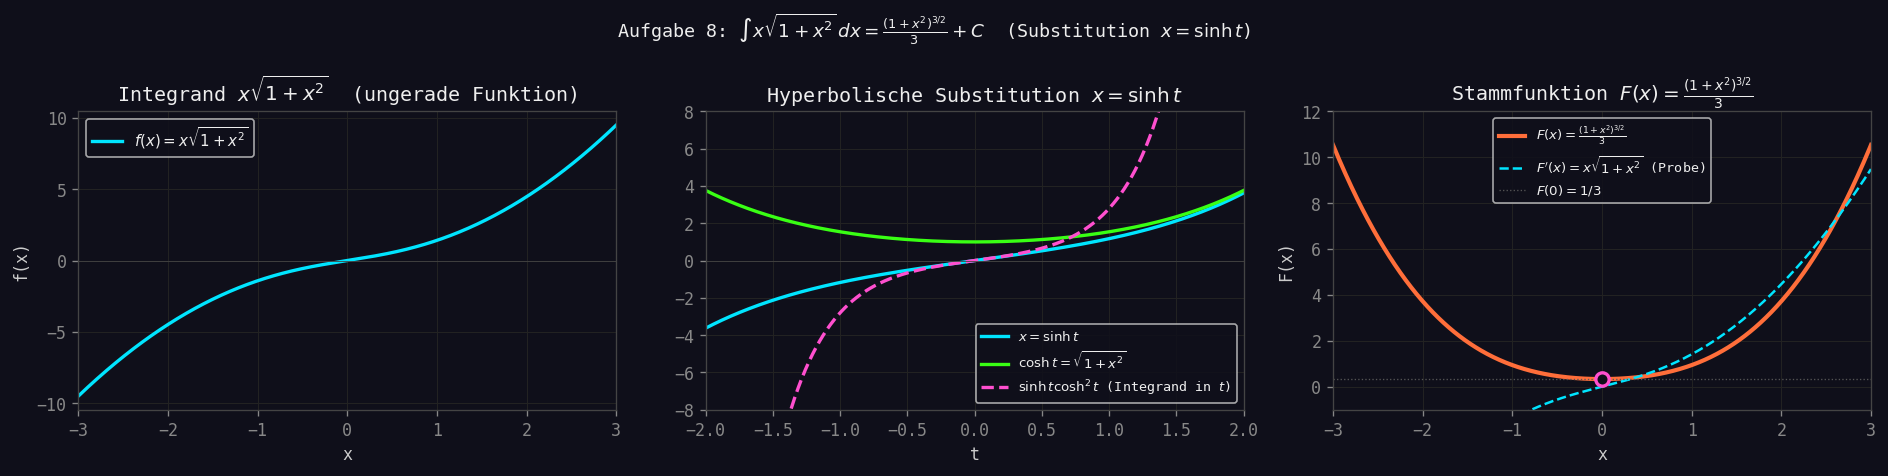

In [180]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x_vals = np.linspace(-3, 3, 800)

# Links: Integrand x·√(1+x²)
ax = axes[0]
ax.plot(x_vals, x_vals * np.sqrt(1 + x_vals**2), color=CYAN, lw=2,
        label=r'$f(x) = x\sqrt{1+x^2}$')
ax.axhline(0, color='#444', lw=0.5)
ax.set(xlim=(-3, 3), xlabel='x', ylabel='f(x)',
       title=r'Integrand $x\sqrt{1+x^2}$  (ungerade Funktion)')
ax.grid(True); ax.legend(fontsize=9)

# Mitte: Hyperbolische Funktionen – Geometrie der Substitution
ax = axes[1]
t_vals = np.linspace(-2, 2, 600)
ax.plot(t_vals, np.sinh(t_vals), color=CYAN,   lw=2, label=r'$x = \sinh t$')
ax.plot(t_vals, np.cosh(t_vals), color=GREEN,  lw=2, label=r'$\cosh t = \sqrt{1+x^2}$')
ax.plot(t_vals, np.sinh(t_vals)*np.cosh(t_vals)**2, color=PINK, lw=2, ls='--',
        label=r'$\sinh t\cosh^2 t$ (Integrand in $t$)')
ax.axhline(0, color='#444', lw=0.5)
ax.set(xlim=(-2, 2), ylim=(-8, 8), xlabel='t', ylabel='',
       title=r'Hyperbolische Substitution $x=\sinh t$')
ax.grid(True); ax.legend(fontsize=8)

# Rechts: Stammfunktion (1+x²)^(3/2)/3
ax = axes[2]
F8_num = (1 + x_vals**2)**1.5 / 3
ax.plot(x_vals, F8_num, color=ORANGE, lw=2.5,
        label=r'$F(x) = \frac{(1+x^2)^{3/2}}{3}$')
ax.plot(x_vals, x_vals*np.sqrt(1+x_vals**2), color=CYAN, lw=1.5, ls='--',
        label=r"$F'(x) = x\sqrt{1+x^2}$ (Probe)")
ax.axhline(Rational(1,3), color='#555', lw=0.8, ls=':',
           label=r'$F(0) = 1/3$')
ax.plot(0, 1/3, 'o', color=PINK, markersize=8,
        markerfacecolor='#0f0f1a', markeredgewidth=2)
ax.set(xlim=(-3, 3), ylim=(-1, 12), xlabel='x', ylabel='F(x)',
       title=r'Stammfunktion $F(x) = \frac{(1+x^2)^{3/2}}{3}$')
ax.grid(True); ax.legend(fontsize=8)

fig.suptitle(r'Aufgabe 8: $\int x\sqrt{1+x^2}\,dx = \frac{(1+x^2)^{3/2}}{3} + C$  '
             r'(Substitution $x=\sinh t$)', fontsize=11)
plt.tight_layout()
plt.show()